### Stochastic interpolant demo: uniform angles → 1D classical XY chain

A minimal, self-contained illustration of the `eesi` interpolant framework on the
**periodic angle manifold** $(S^1)^N$, using the recently implemented XY-model
pieces (`xyEESI`, `XYChainGNN`, and the `classicalXY` Monte-Carlo sampler).

We learn a generative map from a simple **base** to a physical **target**:

- **Base** $p_0$: independent uniform angles on the circle — trivial to sample.
- **Target** $p_1$: Boltzmann configurations of the 1D classical XY chain,
  $E(\theta) = J\sum_i \cos(\theta_{i+1}-\theta_i)$, drawn with the Metropolis
  sampler in `experiments/classicalXY.py`.

`xyEESI` overrides the Euclidean interpolant with the minimum-image **geodesic**
on $(S^1)^N$, training a tangent-space drift $b(t,x)$ and score $s(t,x)$ along

$$x_t = \mathrm{wrap}\!\big(x_0 + \beta(t)\,d + \gamma(t)\,z\big),\quad d=\mathrm{wrap}(x_1-x_0),\ z\sim N(0,I),$$

so it pairs with the wrap-aware `XYChainGNN`, whose output is a per-spin tangent
scalar. This notebook runs the full pipeline — **data**, **model**, **training**,
**sampling**, and **entropy** — on a deliberately tiny **two-spin** chain, as an
end-to-end smoke test before scaling up.

### 0. Imports & environment

In [1]:
# --- imports & environment ---
import sys
import pathlib

import numpy as np
import torch
import matplotlib.pyplot as plt

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break
from eesi import xyEESI, XYChainGNN

# The classical-XY Monte-Carlo sampler lives alongside this notebook.
_exp = _cwd if (_cwd / "classicalXY.py").exists() else _cwd / "experiments"
sys.path.insert(0, str(_exp))
from classicalXY import mcxy

%matplotlib inline
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. Base and target distributions

The **target** is a set of Boltzmann configurations of the XY chain, generated
once with the Metropolis sampler `classicalXY.mcxy` and held fixed (as if `p_1`
were expensive to sample). MC angles come out on $[0, 2\pi)$; we wrap them onto
$(-\pi, \pi]$ for a canonical range — the network is wrap-invariant either way.

The **base** is independent uniform angles on the circle, drawn fresh (and
cheaply) each training step.

We start with a tiny `N = 2` spin chain purely to check the pipeline runs
end-to-end; bump `N` (and `n_neighbors`, network width, iterations) to scale up.

In [2]:
N = 2            # a tiny two-spin chain — just enough to exercise the whole pipeline
J = 1.0          # ferromagnetic coupling of the target Boltzmann distribution

# --- target p_1: XY-chain Boltzmann samples from the classical MC sampler ---
confs, eners = mcxy(L=N, J=J, n_eq=2_000, n_prod=200_000, n_save=5_000)
x1_all = torch.tensor(confs, dtype=torch.get_default_dtype(), device=device)
# wrap MC angles from [0, 2pi) onto (-pi, pi] (canonical range; network is wrap-invariant)
x1_all = (x1_all + np.pi) % (2 * np.pi) - np.pi
n_data = x1_all.shape[0]
print("target dataset:", tuple(x1_all.shape))


# --- base p_0: independent uniform angles on the circle (trivial to sample) ---
def sample_base(B):
    return torch.rand(B, N, device=device) * (2 * np.pi) - np.pi

Equilibration complete, 99.0%  acceptance.


Equilibration complete, 99.0%  acceptance.
Mean energy: -0.2033269245069083


target dataset: (5000, 2)


### 2. Model & sampler setup

`xyEESI` wraps two `XYChainGNN` fields — the tangent-space drift `net_b` and score
`net_s`. `XYChainGNN` builds a static open-chain graph (`n_neighbors` per side)
and returns a per-spin tangent scalar; for `N = 2` a single neighbour is the
whole chain.

- `path="linear"` gives the geodesic $x_0 + t\,d$ (so $\beta(t)=t$).
- `gamma="sin2"` adds the latent-noise schedule $\gamma(t)=\sin^2(\pi t)$, so the
  score is trained with the cheap antithetic denoising objective (no divergence
  estimate). Try `gamma="quad"`/`"sqrt"`, `gamma="none"` (implicit score
  matching), or `path="trig"`/`"trig2"`.

In [3]:
gnn_kw = dict(N=N, n_neighbors=1, hidden=64, n_layers=4, edge_order=4, time_order=4)
net_b = XYChainGNN(**gnn_kw)
net_s = XYChainGNN(**gnn_kw)

model = xyEESI(
    net_b, net_s,
    d=N,
    path="linear",
    gamma="sin2",
    gamma_scale=1.0,
).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
print("net_b params:", sum(p.numel() for p in model.net_b.parameters()))
print("net_s params:", sum(p.numel() for p in model.net_s.parameters()))

net_b params: 21504
net_s params: 21504


### 3. Training loop

Each iteration draws a random minibatch of target configurations `x1` and a fresh
batch of uniform base angles `x0`. `model.loss` forms the geodesic interpolant
internally and returns the drift/score losses; we minimise their sum.

In [4]:
n_iters = 400
bsize = 4096
hist_b, hist_s = [], []
for it in range(n_iters):
    idx = torch.randint(0, n_data, (bsize,), device=device)
    x1 = x1_all[idx]
    x0 = sample_base(bsize)

    losses = model.loss(x1, x0)          # {"b": drift loss, "s": score loss}
    loss = losses["b"] + losses["s"]

    opt.zero_grad()
    loss.backward()
    opt.step()

    hist_b.append(losses["b"].item())
    hist_s.append(losses["s"].item())
    if it % 50 == 0:
        print(f"iter {it:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")
print(f"iter {it:4d}  loss_b={hist_b[-1]:+.3f}  loss_s={hist_s[-1]:+.3f}")

iter    0  loss_b=-0.000  loss_s=+0.000


iter   50  loss_b=-0.164  loss_s=-0.047


iter  100  loss_b=-0.157  loss_s=-0.033


iter  150  loss_b=-0.115  loss_s=-0.027


iter  200  loss_b=-0.173  loss_s=-0.086


iter  250  loss_b=-0.162  loss_s=-0.101


iter  300  loss_b=-0.178  loss_s=-0.070


iter  350  loss_b=-0.176  loss_s=-0.037


iter  399  loss_b=-0.161  loss_s=-0.088


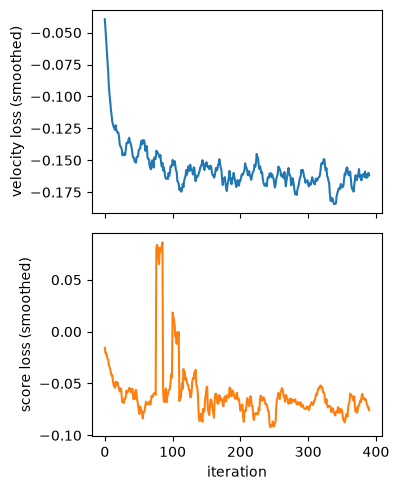

In [5]:
# Training curves (smoothed).
def smooth(v, k=10):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 5))
ax[0].plot(smooth(hist_b), "-C0")
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s), "-C1")
ax[1].set_xlabel("iteration")
ax[1].set_ylabel("score loss (smoothed)")
plt.tight_layout()
plt.show()

### 4. Sampling

Push base samples through the model's built-in samplers (inherited unchanged from
`EESI`):

- `model.sample_ode` integrates the probability-flow **ODE** `dx/dt = b(t, x)`.
- `model.sample_sde` integrates the reverse-time **SDE** using both `b` and `s`.

For a 1D XY chain there is no simple closed-form density to score against, so we
compare two physical observables of the generated vs. true target configurations:
the wrapped nearest-neighbour angle difference $\Delta\theta$ and the per-chain
energy $E=J\sum_i\cos\Delta\theta_i$.

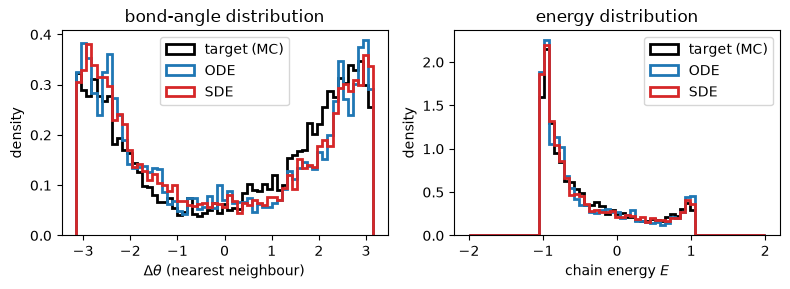

target (MC)   <E> = -0.4067   std(E) = 0.6175
ODE           <E> = -0.4225   std(E) = 0.6305
SDE           <E> = -0.4239   std(E) = 0.6246


In [6]:
torch.manual_seed(1)
n_gen = 5000
x0 = sample_base(n_gen)
gen_ode = model.sample_ode(x0, n_steps=100)             # probability-flow ODE (drift only)
gen_sde = model.sample_sde(x0, n_steps=100, eps=0.3)    # reverse-time SDE (drift + score)


def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def dtheta(x):                       # wrapped nearest-neighbour angle differences
    return wrap(x[:, 1:] - x[:, :-1]).reshape(-1).cpu().numpy()

def chain_energy(x):                 # E = J * sum_i cos(dtheta_i)
    return (J * torch.cos(wrap(x[:, 1:] - x[:, :-1])).sum(-1)).cpu().numpy()


fig, ax = plt.subplots(1, 2, figsize=(8, 3))
bins = np.linspace(-np.pi, np.pi, 60)
for x, lbl, c in [(x1_all, "target (MC)", "k"), (gen_ode, "ODE", "C0"), (gen_sde, "SDE", "C3")]:
    ax[0].hist(dtheta(x), bins=bins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[0].set_xlabel(r"$\Delta\theta$ (nearest neighbour)"); ax[0].set_ylabel("density")
ax[0].set_title("bond-angle distribution"); ax[0].legend()

ebins = np.linspace(-N + 1 - 1, N - 1 + 1, 60)
for x, lbl, c in [(x1_all, "target (MC)", "k"), (gen_ode, "ODE", "C0"), (gen_sde, "SDE", "C3")]:
    ax[1].hist(chain_energy(x), bins=ebins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[1].set_xlabel("chain energy $E$"); ax[1].set_ylabel("density")
ax[1].set_title("energy distribution"); ax[1].legend()
plt.tight_layout()
plt.show()

for x, lbl in [(x1_all, "target (MC)"), (gen_ode, "ODE"), (gen_sde, "SDE")]:
    e = chain_energy(x)
    print(f"{lbl:12s}  <E> = {e.mean():+.4f}   std(E) = {e.std():.4f}")

### 5. Entropy estimates

The differential-entropy change between base and target, estimated three ways
(all inherited from `EESI`, and all just as valid on the geodesic interpolant):

- `entropy_estimate_dot`: mean of $-b\cdot s$ sampled on the interpolant (needs the score).
- `entropy_estimate_div`: mean of $\nabla\!\cdot b$ (score-free, Hutchinson divergence).
- `sample_ode_entropy_traj`: the running integral $-\int_0^t b\cdot s\,dt'$ along ODE paths.

entropy estimate (b·s)   : -0.1749 ± 0.0067
entropy estimate (div b) : -0.1398 ± 0.0167


entropy estimate (ODE path integral): -0.1728


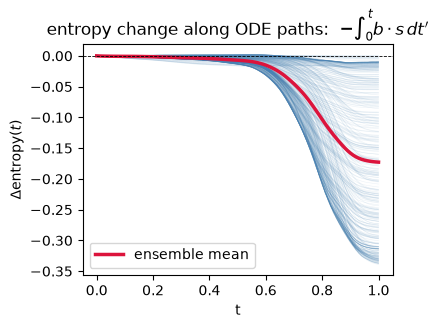

In [7]:
torch.manual_seed(2)
batch = 2000
means_dot, means_div = [], []
for _ in range(50):
    idx = torch.randint(0, n_data, (batch,), device=device)
    x1 = x1_all[idx]
    x0 = sample_base(batch)
    means_dot.append(model.entropy_estimate_dot(x1, x0).mean().item())
    means_div.append(model.entropy_estimate_div(x1, x0).mean().detach().item())

print(f"entropy estimate (b·s)   : {np.mean(means_dot):+.4f} ± {np.std(means_dot):.4f}")
print(f"entropy estimate (div b) : {np.mean(means_div):+.4f} ± {np.std(means_div):.4f}")

# Running entropy change along many ODE paths.
x0 = sample_base(5000)
traj, ent_traj, ts = model.sample_ode_entropy_traj(x0, n_steps=100)
ts_c, ent_c = ts.cpu().numpy(), ent_traj.cpu().numpy()
print(f"entropy estimate (ODE path integral): {ent_c[-1].mean():+.4f}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c[:, :500], c="steelblue", lw=0.4, alpha=0.1)
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta$entropy$(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
ax.legend()
plt.show()